# tRMMGKS vs RMMGKS — 2-D Deblurring Benchmark

This notebook compares the **tensor RMMGKS** (`tRMMGKS`) and the **matrix RMMGKS** (`RMMGKS`) solvers on a 2-D image deblurring problem under circular (periodic) boundary conditions.

**What we measure**
- Relative reconstruction error `||x_k - x_true|| / ||x_true||` per iteration
- Regularization parameter history
- Wall-clock time per solver
- Visual comparison of reconstructions

**Problem setup**
- Image: `satellite` (or `blocks`) at resolution `nx × ny`
- Blur kernel: 2-D Gaussian
- Noise: additive white Gaussian at a chosen SNR
- Regularization: isotropic first-order differences (TV-like)

## 1. Imports

In [75]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- trips package (adjust path if needed) ---
from ttrips.tensors.ops import t_prod2, t_transpose
from ttrips.tensors.build import build_tensor_A, build_circular_H, tensorize, unfold
from ttrips.tensors.derivatives import Lx_tensor, Ly_tensor, t_vstack, gen_first_derivative_operator_2D_circular
from ttrips.solvers.trmmgks import tRMMGKS

# --- matrix solver (assumed importable from your existing code) ---
from ttrips.solvers.rmmgks import RMMGKS

# --- test problem helpers ---
from trips.test_problems.Deblurring2D import Deblurring2D
from helpers import *
print('All imports OK.')

All imports OK.


## 2. Helper: Gaussian kernel

In [76]:
def gaussian_kernel_2d(k: int, sigma: float = None) -> np.ndarray:
    """
    Build a k×k isotropic Gaussian PSF, normalized to sum to 1.
    If sigma is None an OpenCV-style heuristic is used.
    """
    if sigma is None:
        sigma = max(0.5, 0.3 * (k // 2 - 1) + 0.8)
    center = (k - 1) / 2
    x = np.arange(k) - center
    X, Y = np.meshgrid(x, x, indexing='ij')
    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return kernel / kernel.sum()

## 3. Experiment configuration

Edit the cells below to change the image, blur, noise level, or solver settings.

In [77]:
# ── Image & blur ─────────────────────────────────────────────────────────────
IMAGE_NAME   = 'blocks'   # 'satellite' | 'blocks' | any name accepted by Deblurring2D
NX, NY       = [32]*2       # image dimensions (keep equal for the tensor solver)
KERNEL_SIZE  = 13             # Gaussian kernel side length (odd)
KERNEL_SIGMA = None          # None → heuristic; or pass a float, e.g. 1.5

# ── Noise ────────────────────────────────────────────────────────────────────
NOISE_LEVEL  = 0.01          # relative noise: e = noise_level * ||b_true|| / ||n|| * n

# ── Shared solver settings ───────────────────────────────────────────────────
N_ITER         = 30          # outer iterations for both solvers
PROJECTION_DIM = 3           # initial Krylov subspace size
KMIN           = 3           # subspace size after recycling
L_MAX          = 15          # max subspace size before recycling
PNORM          = 2           # fidelity exponent
QNORM          = 1           # regularization exponent (1 → TV-like)
EPSILON        = 0.1         # MM smoothing parameter

# ── Regularization parameter ─────────────────────────────────────────────────
# Use a fixed float or 'gcv'/'dp' depending on what each solver supports.
REG_PARAM_TENSOR = 1e-4      # λ for tRMMGKS  ('gcv' once _estimate_lambda_tensor is wired up)
REG_PARAM_MATRIX = 'dp'      # λ for RMMGKS   ('dp' uses the Discrepancy Principle)

## 4. Build problem

In [80]:
# ── True image ────────────────────────────────────────────────────────────────
Deblur2D = Deblurring2D(CommitCrime=True)
if IMAGE_NAME=='satellite':
    x_true_2d = Deblur2D.gen_true(im=IMAGE_NAME, nx=NX, ny=NY)  # (NX, NY)
else:
    x_true_2d = generate_problem(phantom_name=IMAGE_NAME, nx=NX
                           , ny=NY, t_end=1
                           , v_max=1, v_min=0, padding=1, root='',add =0)['u_traj'][0].reshape(NX,NY)
x_true_2d+=np.random.normal(0,1, size=x_true_2d.shape)*0.05
x_true     = x_true_2d.reshape(-1, 1)                        # (NX*NY, 1) column vector
X_true     = tensorize(x_true_2d)                            # (NX, 1, NY) lateral slice tensor

# ── PSF and forward operators ─────────────────────────────────────────────────
kernel = gaussian_kernel_2d(KERNEL_SIZE, KERNEL_SIGMA)
H      = build_circular_H(kernel, (NX, NY))                  # (NX*NY, NX*NY) matrix
H_T    = build_tensor_A(kernel, NX)                          # (NX, NX, NY)   tensor

# ── Regularization operators ─────────────────────────────────────────────────
Lx_tens = Lx_tensor(NX, NY)
Ly_tens = Ly_tensor(NX, NY)
L_tens  = t_vstack(Lx_tens, Ly_tens)                         # (2*NX, NX, NY) tensor
L_mat   = gen_first_derivative_operator_2D_circular(NX, NY)  # (2*NX*NY, NX*NY) sparse matrix

# ── Blurred clean data ────────────────────────────────────────────────────────
B_clean_T = t_prod2(H_T, X_true)                             # (NX, 1, NY) tensor
B_clean   = H @ x_true                                       # (NX*NY, 1) vector

# ── Add noise ─────────────────────────────────────────────────────────────────
rng   = np.random.default_rng(seed=42)
noise = rng.standard_normal(B_clean.shape)
e     = NOISE_LEVEL * la.norm(B_clean) / la.norm(noise) * noise
delta = la.norm(e)                                           # noise level for DP

B_noisy   = B_clean   + e
B_noisy_T = B_clean_T + e.reshape(NX, 1, NY)                # reshape noise to tensor form

print(f'Image      : {IMAGE_NAME}  ({NX}×{NY})')
print(f'Kernel     : {KERNEL_SIZE}×{KERNEL_SIZE} Gaussian')
print(f'Noise level: {NOISE_LEVEL}  (||e|| = {delta:.4f})')
print(f'SNR        : {20*np.log10(la.norm(B_clean)/delta):.1f} dB')

Problem Description:
- Phantom: blocks
- Image size: 32 x 32
- Number of frames: 1
- Output directory: /problem_32_by_32_blocks_20260424_094225

Image      : blocks  (32×32)
Kernel     : 13×13 Gaussian
Noise level: 0.01  (||e|| = 0.1021)
SNR        : 40.0 dB


In [ ]:

from helpers import *
views = 60


theta = np.linspace(0, 180, views, endpoint=False)
H = create_forward_op_ct(NX,NY, theta=theta,s=2)
# ── Blurred clean data ────────────────────────────────────────────────────────
                            # (NX, 1, NY) tensor
B_clean   = H @ x_true   
rng   = np.random.default_rng(seed=42)
noise = rng.standard_normal(B_clean.shape) 
e     = NOISE_LEVEL * la.norm(B_clean) / la.norm(noise) * noise                                   # (NX*NY, 1) vector
B_noisy   = B_clean   + e

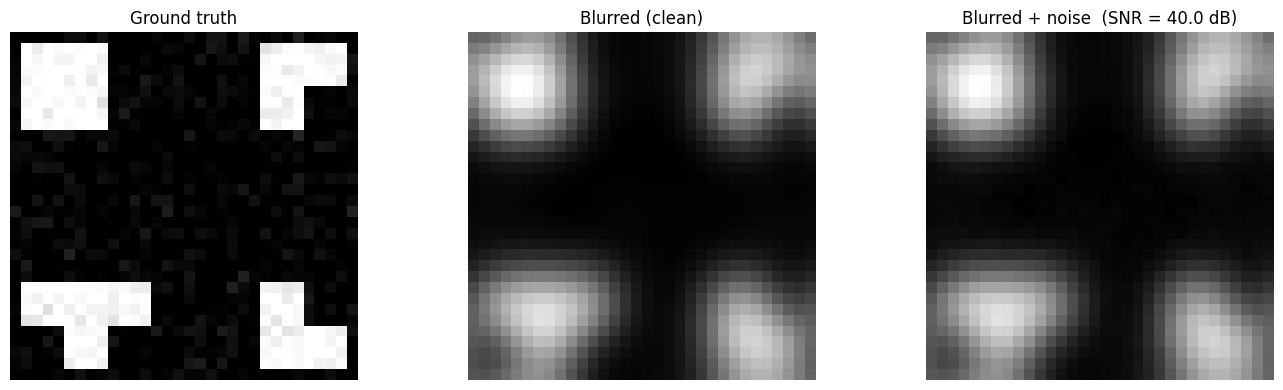

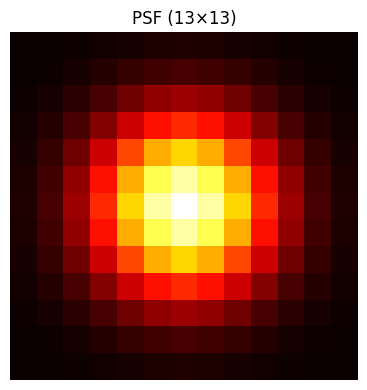

In [81]:
# ── Visualise the problem setup ───────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].imshow(x_true_2d, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('Ground truth')
axs[0].axis('off')

axs[1].imshow(B_clean.reshape(NX, NY), cmap='gray')
axs[1].set_title('Blurred (clean)')
axs[1].axis('off')

axs[2].imshow(B_noisy.reshape(NX, NY), cmap='gray')
axs[2].set_title(f'Blurred + noise  (SNR = {20*np.log10(la.norm(B_clean)/delta):.1f} dB)')
axs[2].axis('off')

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(4, 4))
ax2.imshow(kernel, cmap='hot')
ax2.set_title(f'PSF ({KERNEL_SIZE}×{KERNEL_SIZE})')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [6]:
from ttrips.solvers.gkb import t_gkb
U,S,V = t_gkb(H_T,B_clean_T)

TypeError: t_gkb() missing 1 required positional argument: 'k'

## 5. Run tRMMGKS (tensor solver)

In [82]:
print('Running tRMMGKS...')
t0 = time.perf_counter()


N_ITER         = 30          # outer iterations for both solvers
PROJECTION_DIM = 3           # initial Krylov subspace size
KMIN           = 3           # subspace size after recycling
L_MAX          = 10          # max subspace size before recycling
PNORM          = 2           # fidelity exponent
QNORM          = 2          # regularization exponent (1 → TV-like)
EPSILON        = 0.01         # MM smoothing parameter

lambda_min =  1e-6
lambda_max =  10
n_lambda   = 20

# ── Regularization parameter ─────────────────────────────────────────────────
# Use a fixed float or 'gcv'/'dp' depending on what each solver supports.
REG_PARAM_TENSOR = 'gridsearch'      # λ for tRMMGKS  ('gcv' once _estimate_lambda_tensor is wired up)
     # λ for RMMGKS   ('dp' uses the Discrepancy Principle)

x_tens, info_tens = tRMMGKS(
    A_tens         = H_T,
    b_tens         = B_noisy_T,
    L_tens         = L_tens,
    qnorm          = QNORM,
    pnorm          = PNORM,
    projection_dim = PROJECTION_DIM,
    n_iter         = N_ITER,
    epsilon        = EPSILON,
    regparam       = REG_PARAM_TENSOR,
    x_true         = X_true,
    kmin           = KMIN,
    l_max          = L_MAX,
    tol            = 1e-12,
    parallel       = True,
    lambda_min =  lambda_min,
    lambda_max =  lambda_max,
    n_lambda   = n_lambda

)

time_tens = time.perf_counter() - t0
print(f'  Done in {time_tens:.2f} s')
print(f'  Final relative error : {info_tens["relError"][-1]:.6f}')

Running tRMMGKS...
[0.3211506734755004, 0.3211480026082554, 0.3211417732875979, 0.3211272727708298, 0.32109367203053685, 0.32101663804896396, 0.3208444029138238, 0.32048161252758, 0.3198217495669391, 0.31902985976651443, 0.3192692950455748, 0.3225246070070611, 0.32876486237193375, 0.3360883492963861, 0.3456415221961589, 0.3644699923704456, 0.40335193872495534, 0.4644691926441123, 0.5405292326339095, 0.6329240577175526]
[0.3393094236284733, 0.3393064926910804, 0.3392996487838719, 0.3392836739332773, 0.339246418926376, 0.3391597157495356, 0.33895890044072735, 0.3384989384759292, 0.33747193783420937, 0.33530581864414877, 0.3312561447723213, 0.32524448874849404, 0.3191422285866087, 0.31581674528082687, 0.3172385991018763, 0.32682728807665246, 0.35251880631045635, 0.3997635940984293, 0.4590244401722324, 0.5178012712501908]
[0.36775803125424095, 0.367739264692394, 0.36769557402471564, 0.36759429857735804, 0.36736190299314075, 0.36684095349566204, 0.36573390352840246, 0.363645296673687, 0.360

In [30]:

lambda_min =  1e-10
lambda_max =  10
n_lambda   = 20

In [ ]:
np.log(np.logspace(1e-6,1e-4,2))

array([2.30258509e-06, 2.30258509e-04])

## 6. Run RMMGKS (matrix solver)

In [25]:

from helpers import *
views = 30


theta = np.linspace(0, 180, views, endpoint=False)
H = create_forward_op_ct(NX,NY, theta=theta,s=2)
# ── Blurred clean data ────────────────────────────────────────────────────────
                            # (NX, 1, NY) tensor
B_clean   = H @ x_true   
rng   = np.random.default_rng(seed=42)
noise = rng.standard_normal(B_clean.shape) 
NOISE_LEVEL=0.1
e     = NOISE_LEVEL * la.norm(B_clean) / la.norm(noise) * noise                                   # (NX*NY, 1) vector
B_noisy   = B_clean   + e
delta = la.norm(B_clean-B_noisy)

In [85]:
print('Running RMMGKS (matrix)...')
t0 = time.perf_counter()


PROJECTION_DIM = 3           # initial Krylov subspace size
KMIN           = 20          # subspace size after recycling
L_MAX          = 25          # max subspace size before recycling

# ── Regularization parameter ─────────────────────────────────────────────────
REG_PARAM_MATRIX = 'gridsearch'     # λ for RMMGKS   ('dp' uses the Discrepancy Principle)

x_mat, info_mat, _, _ = RMMGKS(
    H,
    B_noisy, #unfold(B_noisy_T),          # unfold tensor RHS to matrix form
    L_mat,
    pnorm          = PNORM,
    qnorm          = QNORM,
    projection_dim = PROJECTION_DIM,
    regparam       = REG_PARAM_MATRIX,
    delta          = delta,
    n_iter         = N_ITER,
    x_true         = x_true,
    kmin           = KMIN,
    l_max          = L_MAX,
    x0             = None,
    explicitProj   = True,
    lambda_min =  lambda_min,
    lambda_max =  lambda_max,
    n_lambda   = n_lambda,
    compute_V = False,
    plot = True
)

time_mat = time.perf_counter() - t0
print(f'  Done in {time_mat:.2f} s')
print(f'  Final relative error : {info_mat["relError"][-1]:.6f}')

Running RMMGKS (matrix)...


running MMGKS...:  13%|█▎        | 4/30 [00:00<00:00, 33.74it/s]

[0.524401261371091, 0.5244012582153726, 0.5244012508945746, 0.5244012340682768, 0.5244011962541401, 0.5244011160172714, 0.5244009723652977, 0.5244008711030218, 0.524401858336167, 0.524410216574949, 0.5244564226375216, 0.5246592190184506, 0.525376551528744, 0.5275068842490416, 0.5332853845531662, 0.5479793592327663, 0.5794544166108836, 0.6279466039545758, 0.6808087348672324, 0.730711067320073]
[0.49769448030979774, 0.4976944815123368, 0.4976944843939578, 0.4976944915216844, 0.49769451033325535, 0.49769456603491147, 0.4976947598277326, 0.4976955538742597, 0.4976991972804969, 0.4977166176488276, 0.49779729291839875, 0.49813450358905587, 0.4993515170208473, 0.5032032681086688, 0.5140965671744021, 0.5393023370358929, 0.5809581155275486, 0.6305681023134115, 0.6811385994979836, 0.7307254102635714]
[0.4901971122309704, 0.49019717219873926, 0.49019731231209207, 0.49019763982513515, 0.4901984061518968, 0.49020020340982834, 0.4902044410588601, 0.49021455284191023, 0.49023930013690414, 0.490302828

running MMGKS...:  40%|████      | 12/30 [00:00<00:00, 31.71it/s]


[0.45161423516112764, 0.4516151666246445, 0.45161734244847535, 0.4516224255722123, 0.45163430380220404, 0.45166207767411853, 0.45172710885354433, 0.4518798403410639, 0.4522407621348281, 0.4531022667208576, 0.45517256661141764, 0.4600065818280534, 0.4699862985441575, 0.4864346818500662, 0.5091842188900204, 0.5406958135013573, 0.5826860877868855, 0.6310110488021845, 0.681196991776635, 0.7307634110123943]
[0.4481174670510884, 0.4481185800977762, 0.44812118011016217, 0.4481272543515179, 0.44814144935558553, 0.44817464428055787, 0.44825238923236554, 0.4484350825102565, 0.4488672432745769, 0.44989981590950656, 0.4523745094874374, 0.4580484920839015, 0.4691982547586096, 0.48634002789390063, 0.5091112997478624, 0.5406109151451987, 0.5826652211534585, 0.6310237165921299, 0.6812036018377011, 0.7307641171233246]
[0.44318931522901045, 0.44319090458702254, 0.4431946170535892, 0.44320328926053754, 0.4432235501021208, 0.44327090055009555, 0.44338163883444814, 0.4436409965142137, 0.4442498539349368, 

...

[0.3721302071341305, 0.3721720234854199, 0.372269848899589, 0.3724991433630975, 0.37303860924857424, 0.3743144555285944, 0.3773257416131381, 0.38411991830307185, 0.39721547234622356, 0.4159709442976947, 0.4355252322294138, 0.4530131516163859, 0.46938425927704974, 0.4870691633522725, 0.5093504699626412, 0.540705914055216, 0.5827322015921916, 0.6310559770835735, 0.681214438599145, 0.7307687383625794]
[0.3693819858128419, 0.36942451115740793, 0.3695241303059164, 0.36975834164486826, 0.37031296700053296, 0.3716409615777308, 0.3748331423884773, 0.3821452266014002, 0.3961737372579212, 0.4157284878978828, 0.4355291123381509, 0.45301971484770215, 0.4693819756290616, 0.4870678486629835, 0.5093533241830962, 0.5407092692799059, 0.5827320116995321, 0.6310544309225207, 0.681213903561692, 0.7307686764335932]
[0.3657367369558097, 0.3657758475810187, 0.36586789178277057, 0.3660865274780943, 0.3666154826734317, 0.36793251048058023, 0.3712760157206655, 0.37928905010053865, 0.3947083283357813, 0.41540911

running MMGKS...:  83%|████████▎ | 25/30 [00:00<00:00, 23.57it/s]

[0.3611780191661299, 0.3611814649808904, 0.36118954475759846, 0.3612085871169576, 0.36125398622912064, 0.36136496048930483, 0.36164994209668233, 0.3624426079637023, 0.36483946306430687, 0.3721012900324589, 0.3904522666973986, 0.4221693094145046, 0.4571862783812285, 0.4857757112429439, 0.5108761573451386, 0.5419365229129371, 0.5833773434204431, 0.6313505514009047, 0.6813335297367551, 0.7308153097976842]
[0.36010736621089706, 0.36011309521589585, 0.36012651308918525, 0.3601580517426142, 0.3602327865883201, 0.360413027993077, 0.36086316126879286, 0.3620521192686397, 0.36536240412589327, 0.37431519651491907, 0.3942014364473899, 0.4253271079947514, 0.45865774900796474, 0.4863502606171356, 0.5111570499228985, 0.5420618281244562, 0.5834113322490407, 0.6313575827838547, 0.68133726134795, 0.7308173206943606]
[0.3571277270856226, 0.35713674676598817, 0.3571578554965146, 0.3572073825634309, 0.35732425282799957, 0.35760337881802756, 0.35828499477384035, 0.35999873301578467, 0.36434006359978705, 0.

running MMGKS...: 100%|██████████| 30/30 [00:01<00:00, 25.15it/s]

[0.35646132760626525, 0.35646391107444314, 0.3564699595556073, 0.35648416452419496, 0.35651776345734876, 0.3565985053755672, 0.35679910309871704, 0.35732894546622307, 0.35885273642178456, 0.3634901362077152, 0.37658031629071625, 0.40447629955724124, 0.4431612892261213, 0.4794626057874769, 0.5099337322099943, 0.5427332645614648, 0.584117664854108, 0.6317532511536932, 0.6815127525169973, 0.7308890461728338]
[0.35632803707867916, 0.35633093344320155, 0.35633771318823415, 0.35635362848767044, 0.35639123461694294, 0.3564814007906055, 0.3567043292640357, 0.3572876695188884, 0.3589395704763375, 0.3638602209233148, 0.37739680995487335, 0.40552169767493085, 0.44389642432297716, 0.47978636295266086, 0.5100419284308454, 0.5427625462443707, 0.5841238480066894, 0.631753901272819, 0.6815123853286627, 0.730888838029372]
[0.3552806910990605, 0.3552901892985659, 0.35531241347923864, 0.35536453425700043, 0.35548740561703923, 0.3557803137816812, 0.35649363357244035, 0.3582847395735902, 0.3628369756356115

## 7. Convergence comparison

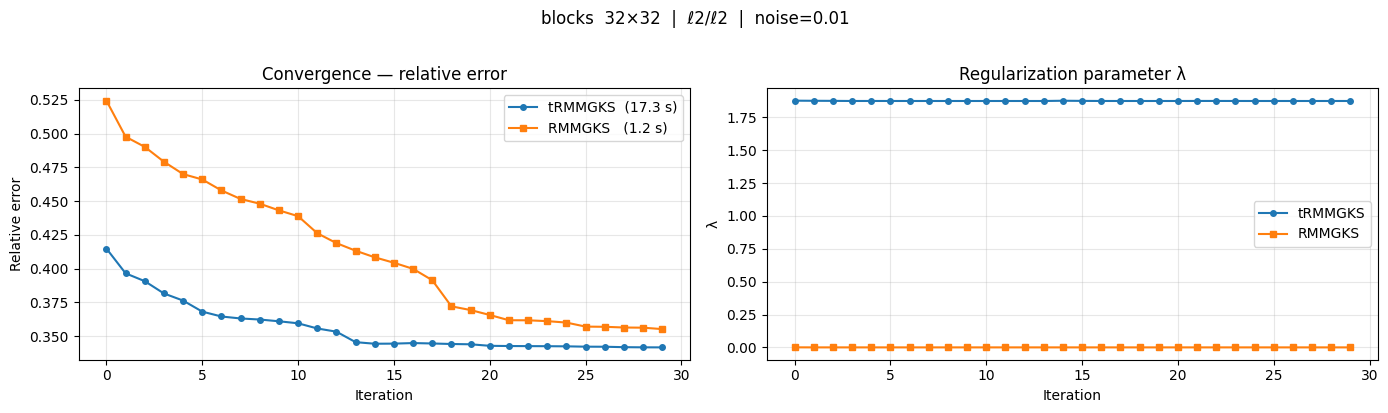

In [87]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# ── Relative error ────────────────────────────────────────────────────────────
axs[0].plot(info_tens['relError'], '-o', markersize=4, label=f'tRMMGKS  ({time_tens:.1f} s)')
axs[0].plot(info_mat['relError'],  '-s', markersize=4, label=f'RMMGKS   ({time_mat:.1f} s)')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Relative error')
axs[0].set_title('Convergence — relative error')
axs[0].legend()
axs[0].grid(True, which='both', alpha=0.3)

# ── Regularization parameter history ─────────────────────────────────────────
#
axs[1].plot(np.array(info_tens['regParam_history']).mean(axis = 1), '-o', markersize=4, label='tRMMGKS')
axs[1].plot(info_mat['regParam_history'],  '-s', markersize=4, label='RMMGKS')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('λ')
axs[1].set_title('Regularization parameter λ')
axs[1].legend()
axs[1].grid(True, which='both', alpha=0.3)

plt.suptitle(
    f'{IMAGE_NAME}  {NX}×{NY}  |  ℓ{PNORM}/ℓ{QNORM}  |  noise={NOISE_LEVEL}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

## 8. Reconstruction quality

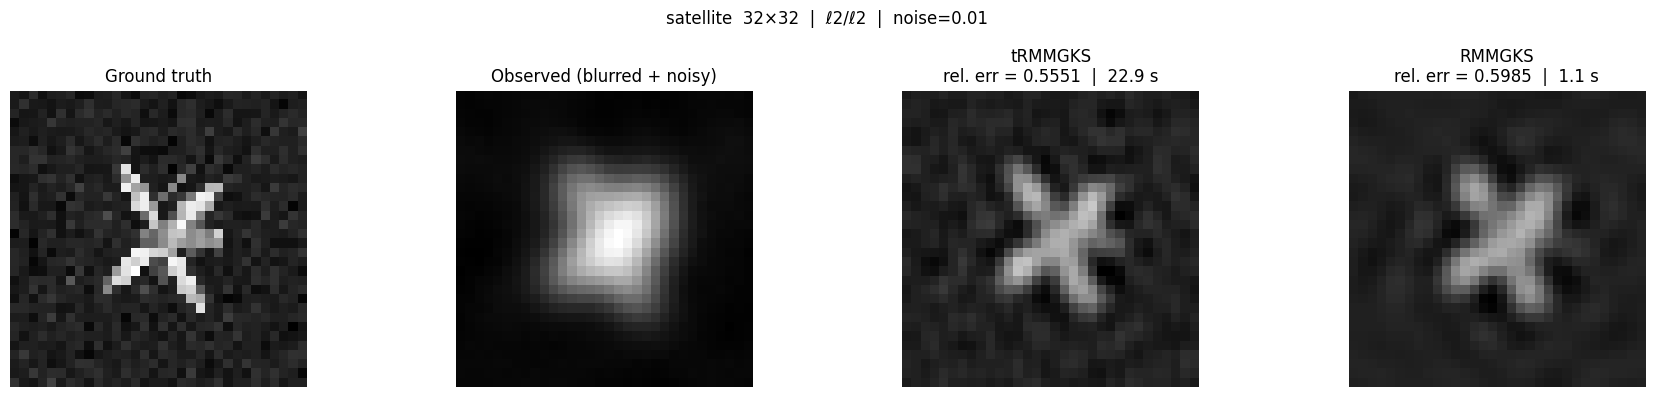

In [34]:
# Reshape reconstructions to 2-D images
# tRMMGKS returns a (NX, 1, NY) lateral slice tensor
x_tens_2d = unfold(x_tens).reshape(NX,NY)                      # (NX, NY)
# RMMGKS returns a flat vector (NX*NY, 1)
x_mat_2d  = x_mat.reshape(NX, NY)

vmin, vmax = x_true_2d.min(), x_true_2d.max()

fig, axs = plt.subplots(1, 4, figsize=(18, 4))

axs[0].imshow(x_true_2d,  cmap='gray', vmin=vmin, vmax=vmax)
axs[0].set_title('Ground truth')
axs[0].axis('off')

axs[1].imshow(B_noisy.reshape(NX, NY), cmap='gray')
axs[1].set_title('Observed (blurred + noisy)')
axs[1].axis('off')

err_tens = la.norm(x_tens_2d - x_true_2d) / la.norm(x_true_2d)
axs[2].imshow(x_tens_2d, cmap='gray', vmin=vmin, vmax=vmax)
axs[2].set_title(f'tRMMGKS\nrel. err = {err_tens:.4f}  |  {time_tens:.1f} s')
axs[2].axis('off')

err_mat = la.norm(x_mat_2d - x_true_2d) / la.norm(x_true_2d)
axs[3].imshow(x_mat_2d, cmap='gray', vmin=vmin, vmax=vmax)
axs[3].set_title(f'RMMGKS\nrel. err = {err_mat:.4f}  |  {time_mat:.1f} s')
axs[3].axis('off')

plt.suptitle(
    f'{IMAGE_NAME}  {NX}×{NY}  |  ℓ{PNORM}/ℓ{QNORM}  |  noise={NOISE_LEVEL}',
    fontsize=12
)
plt.tight_layout()
plt.show()

## 9. Error images

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

err_img_tens = np.abs(x_tens_2d - x_true_2d)
err_img_mat  = np.abs(x_mat_2d  - x_true_2d)
emax = max(err_img_tens.max(), err_img_mat.max())

im0 = axs[0].imshow(err_img_tens, cmap='hot', vmin=0, vmax=emax)
axs[0].set_title(f'|tRMMGKS − truth|  (max={err_img_tens.max():.4f})')
axs[0].axis('off')
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(err_img_mat, cmap='hot', vmin=0, vmax=emax)
axs[1].set_title(f'|RMMGKS − truth|  (max={err_img_mat.max():.4f})')
axs[1].axis('off')
plt.colorbar(im1, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 10. Summary table

In [ ]:
import pandas as pd

best_err_tens = min(info_tens['relError'])
best_err_mat  = min(info_mat['relError'])
best_it_tens  = int(np.argmin(info_tens['relError'])) + 1
best_it_mat   = int(np.argmin(info_mat['relError']))  + 1

summary = pd.DataFrame({
    'Solver':             ['tRMMGKS', 'RMMGKS'],
    'Formulation':        ['Tensor (t-product)', 'Matrix'],
    'Final rel. error':   [f'{info_tens["relError"][-1]:.6f}',
                           f'{info_mat["relError"][-1]:.6f}'],
    'Best rel. error':    [f'{best_err_tens:.6f}', f'{best_err_mat:.6f}'],
    'Best at iteration':  [best_it_tens, best_it_mat],
    'Wall-clock time (s)':[f'{time_tens:.2f}', f'{time_mat:.2f}'],
    'Iterations':         [N_ITER, N_ITER],
})

summary = summary.set_index('Solver')
display(summary)

## 11. Sensitivity sweep — noise level

Run both solvers across a range of noise levels and compare best-achieved relative error.

In [ ]:
SWEEP_NOISE_LEVELS = [0.001, 0.005, 0.01, 0.02, 0.05]
SWEEP_N_ITER       = 20    # fewer iterations for speed during the sweep

sweep_results = []

for nl in SWEEP_NOISE_LEVELS:
    # build noisy data
    noise_sw  = rng.standard_normal(B_clean.shape)
    e_sw      = nl * la.norm(B_clean) / la.norm(noise_sw) * noise_sw
    delta_sw  = la.norm(e_sw)
    B_sw      = B_clean   + e_sw
    B_sw_T    = B_clean_T + e_sw.reshape(NX, 1, NY)

    # tRMMGKS
    t0 = time.perf_counter()
    _, info_sw_t = tRMMGKS(
        H_T, B_sw_T, L_tens,
        qnorm=QNORM, pnorm=PNORM,
        projection_dim=PROJECTION_DIM, n_iter=SWEEP_N_ITER,
        epsilon=EPSILON, regparam=REG_PARAM_TENSOR,
        x_true=X_true, kmin=KMIN, l_max=L_MAX, tol=1e-12,
    )
    t_sw_t = time.perf_counter() - t0

    # RMMGKS
    t0 = time.perf_counter()
    _, info_sw_m, _, _ = RMMGKS(
        H, unfold(B_sw_T), L_mat,
        pnorm=PNORM, qnorm=QNORM,
        projection_dim=PROJECTION_DIM,
        regparam=REG_PARAM_MATRIX, delta=delta_sw,
        n_iter=SWEEP_N_ITER, x_true=x_true,
        kmin=KMIN, l_max=L_MAX, x0=None,
        explicitProj=True, tensor_svd=False,
    )
    t_sw_m = time.perf_counter() - t0

    sweep_results.append({
        'noise_level':      nl,
        'best_err_tensor':  min(info_sw_t['relError']),
        'best_err_matrix':  min(info_sw_m['relError']),
        'time_tensor':      t_sw_t,
        'time_matrix':      t_sw_m,
    })
    print(f'  noise={nl:.3f}  |  tRMMGKS err={sweep_results[-1]["best_err_tensor"]:.4f}  |  RMMGKS err={sweep_results[-1]["best_err_matrix"]:.4f}')

print('Sweep done.')

In [ ]:
nls   = [r['noise_level']    for r in sweep_results]
err_t = [r['best_err_tensor'] for r in sweep_results]
err_m = [r['best_err_matrix'] for r in sweep_results]
t_t   = [r['time_tensor']    for r in sweep_results]
t_m   = [r['time_matrix']    for r in sweep_results]

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

axs[0].loglog(nls, err_t, '-o', label='tRMMGKS')
axs[0].loglog(nls, err_m, '-s', label='RMMGKS')
axs[0].set_xlabel('Noise level')
axs[0].set_ylabel('Best relative error')
axs[0].set_title('Reconstruction quality vs noise')
axs[0].legend()
axs[0].grid(True, which='both', alpha=0.3)

axs[1].semilogx(nls, t_t, '-o', label='tRMMGKS')
axs[1].semilogx(nls, t_m, '-s', label='RMMGKS')
axs[1].set_xlabel('Noise level')
axs[1].set_ylabel('Wall-clock time (s)')
axs[1].set_title('Runtime vs noise level')
axs[1].legend()
axs[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Noise-level sweep', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Sensitivity sweep — regularization norm (ℓp/ℓq)

Compare ℓ2/ℓ2 (Tikhonov) vs ℓ2/ℓ1 (TV-like) for both solvers.

In [ ]:
NORM_CONFIGS = [
    {'pnorm': 2, 'qnorm': 2, 'label': 'ℓ2/ℓ2 (Tikhonov)'},
    {'pnorm': 2, 'qnorm': 1, 'label': 'ℓ2/ℓ1 (TV-like)'},
    {'pnorm': 1, 'qnorm': 1, 'label': 'ℓ1/ℓ1'},
]

norm_results = []

for cfg in NORM_CONFIGS:
    _, info_nc_t = tRMMGKS(
        H_T, B_noisy_T, L_tens,
        qnorm=cfg['qnorm'], pnorm=cfg['pnorm'],
        projection_dim=PROJECTION_DIM, n_iter=N_ITER,
        epsilon=EPSILON, regparam=REG_PARAM_TENSOR,
        x_true=X_true, kmin=KMIN, l_max=L_MAX, tol=1e-12,
    )
    _, info_nc_m, _, _ = RMMGKS(
        H, unfold(B_noisy_T), L_mat,
        pnorm=cfg['pnorm'], qnorm=cfg['qnorm'],
        projection_dim=PROJECTION_DIM,
        regparam=REG_PARAM_MATRIX, delta=delta,
        n_iter=N_ITER, x_true=x_true,
        kmin=KMIN, l_max=L_MAX, x0=None,
        explicitProj=True, tensor_svd=False,
    )
    norm_results.append({
        'label':         cfg['label'],
        'err_tensor':    info_nc_t['relError'],
        'err_matrix':    info_nc_m['relError'],
    })
    print(f"  {cfg['label']:20s}  |  tRMMGKS final={info_nc_t['relError'][-1]:.4f}  |  RMMGKS final={info_nc_m['relError'][-1]:.4f}")

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

colors = ['tab:blue', 'tab:orange', 'tab:green']
for res, col in zip(norm_results, colors):
    axs[0].semilogy(res['err_tensor'], '-o', color=col, markersize=3, label=res['label'])
    axs[1].semilogy(res['err_matrix'], '-s', color=col, markersize=3, label=res['label'])

for ax, title in zip(axs, ['tRMMGKS', 'RMMGKS']):
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Relative error')
    ax.set_title(f'{title} — norm comparison')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Intermediate iterates

Visualise how the reconstruction evolves over iterations for tRMMGKS.

In [ ]:
# Pick a few checkpoints to display
checkpoints = [0, N_ITER // 4, N_ITER // 2, N_ITER - 1]
checkpoints = [c for c in checkpoints if c < len(info_tens['xHistory'])]

fig, axs = plt.subplots(1, len(checkpoints) + 1, figsize=(4 * (len(checkpoints) + 1), 4))

axs[0].imshow(x_true_2d, cmap='gray', vmin=vmin, vmax=vmax)
axs[0].set_title('Ground truth')
axs[0].axis('off')

for ax, it in zip(axs[1:], checkpoints):
    xk = info_tens['xHistory'][it][:, 0, :]  # (NX, NY)
    err_k = la.norm(xk - x_true_2d) / la.norm(x_true_2d)
    ax.imshow(xk, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(f'Iter {it + 1}\nerr={err_k:.4f}')
    ax.axis('off')

plt.suptitle('tRMMGKS — iterate evolution', fontsize=12)
plt.tight_layout()
plt.show()